In [2]:

import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r"StudentsPerformance.csv")

print("first 5 rows")
print(df.head())

print("\n Dataset shape")
print(df.shape)

first 5 rows
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

 Dataset shape
(1000, 8)


In [4]:
data = df["math score"].dropna()
print("\n Number of math score values",len(data))


 Number of math score values 1000


In [7]:
col = df["math score"]

Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("\nIQR METHOD")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

iqr_outliers = df[
    (df["math score"] < lower_limit) |
    (df["math score"] > upper_limit)
]

print("Number of IQR outliers:", len(iqr_outliers))


IQR METHOD
Q1: 57.0
Q3: 77.0
IQR: 20.0
Lower limit: 27.0
Upper limit: 107.0
Number of IQR outliers: 8


In [8]:
mean = data.mean()

std=data.std()

df["Z_score"]= (df["math score"] -  mean)/std


z_outliers = df[abs(df["Z_score"])>3]

print("\nZ-SCORE METHOD")

print("Mean",mean)
print("Standard deviation",std)

print("number of z-score outliers",len(z_outliers))


Z-SCORE METHOD
Mean 66.089
Standard deviation 15.163080096009468
number of z-score outliers 4


In [10]:
print("\n IQR outlets")

if len(iqr_outliers)>0:
  print(iqr_outliers[["math score"]])
else:
  print("No IQR outliers found")

print("\n Z-SCORE OUTLIERS")

if len(z_outliers)>0:
  print(z_outliers[["math score","Z_score"]])


 IQR outlets
     math score
17           18
59            0
145          22
338          24
466          26
787          19
842          23
980           8

 Z-SCORE OUTLIERS
     math score   Z_score
17           18 -3.171453
59            0 -4.358547
787          19 -3.105504
980           8 -3.830950


In [13]:
df["math_score_treated"] = df["math score"].clip(
    lower = lower_limit,
    upper=upper_limit
)

print("Treatment method:capping using iqr limits")

print("\n before treatmetn")

print(df["math score"].describe())

print("\n AFTR TREATMENT")
print(df["math_score_treated"].describe())

Treatment method:capping using iqr limits

 before treatmetn
count    1000.00000
mean       66.08900
std        15.16308
min         0.00000
25%        57.00000
50%        66.00000
75%        77.00000
max       100.00000
Name: math score, dtype: float64

 AFTR TREATMENT
count    1000.000000
mean       66.165000
std        14.922414
min        27.000000
25%        57.000000
50%        66.000000
75%        77.000000
max       100.000000
Name: math_score_treated, dtype: float64


In [15]:
comparison = df[["math score","math_score_treated"]]

print(comparison.head(20))

    math score  math_score_treated
0           72                  72
1           69                  69
2           90                  90
3           47                  47
4           76                  76
5           71                  71
6           88                  88
7           40                  40
8           64                  64
9           38                  38
10          58                  58
11          40                  40
12          65                  65
13          78                  78
14          50                  50
15          69                  69
16          88                  88
17          18                  27
18          46                  46
19          54                  54


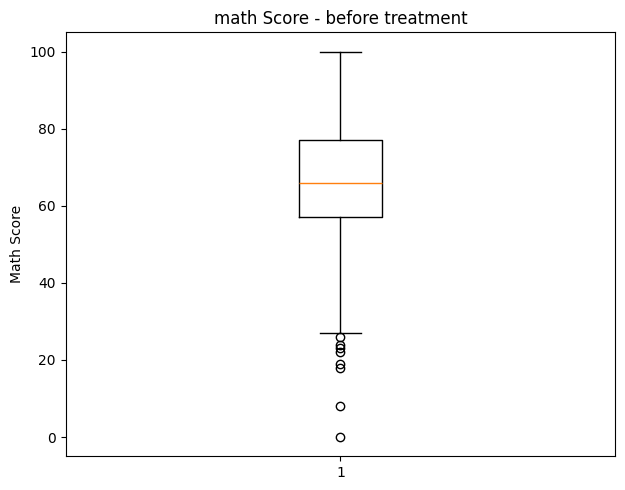

In [18]:
plt.figure(figsize = (12,5))

plt.subplot(1,2,1)
plt.boxplot(df["math score"].dropna())

plt.title("math Score - before treatment")
plt.ylabel("Math Score")
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

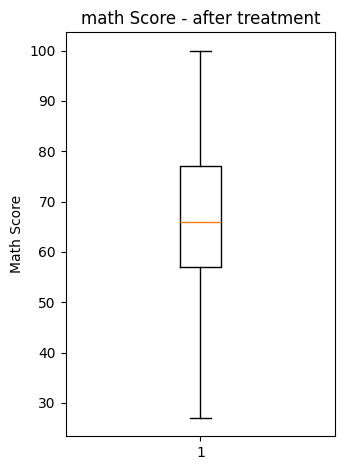

In [19]:
plt.subplot(1,2,2)
plt.boxplot(df["math_score_treated"].dropna())

plt.title("math Score - after treatment")
plt.ylabel("Math Score")
plt.tight_layout()
plt.show()